In [1]:
import os
os.environ['PYTHONHASHSEED'] = '0'

In [2]:
from pyspark import SparkConf, SparkContext

conf = SparkConf().setMaster("local").setAppName("BigData")
# KHÔNG thêm -Djava.security.manager.allow vì dùng Java 21
sc = SparkContext.getOrCreate(conf=conf)

# Test nhanh
rdd = sc.parallelize([1,2,3,4,5])
print("Sum =", rdd.sum())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 21:37:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 0:>                                                          (0 + 1) / 1]

Sum = 15


In [9]:
!pip install numpy
import numpy as np
import matplotlib.pyplot as plt

## 1. Part 01

In [3]:
import sys
sys.path.append('.')
from src.session_01 import get_movie_titles, load_ratings, avg_rating_per_movie, best_movie

In [4]:
movies_path = "data/movies.txt"
ratings_paths = ["data/ratings_1.txt", "data/ratings_2.txt"]

=== Thống kê ratings ===
Tổng số ratings: 100
Số phim có rating: 50

Số ratings mỗi phim: min=2, max=2, avg=2.00
Điểm trung bình: min=3.00, max=4.75, avg=3.86

Không có phim nào đạt 50 ratings. Sẽ tìm phim có rating cao nhất (không giới hạn).

Phim có điểm trung bình cao nhất:  Avatar (2009)
Điểm: 4.75 (2 lượt)


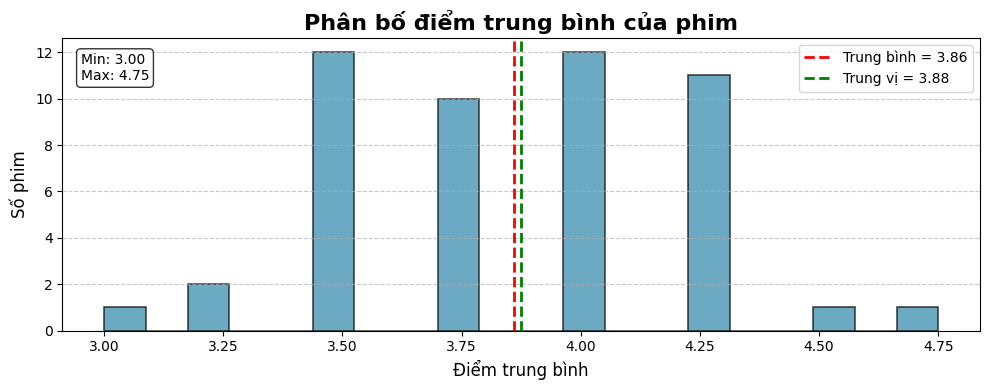

In [11]:
# --- Đọc dữ liệu ---
titles_rdd = get_movie_titles(sc, "data/movies.txt")
ratings_rdd = load_ratings(sc, ["data/ratings_1.txt", "data/ratings_2.txt"])

# --- Tính avg và count cho mỗi phim ---
movie_stats = ratings_rdd.mapValues(lambda r: (r, 1)) \
                         .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1])) \
                         .mapValues(lambda x: (x[0]/x[1], x[1]))  # (avg, count)

# --- Thống kê mô tả ---
print("=== Thống kê ratings ===")
total_ratings = ratings_rdd.count()
print(f"Tổng số ratings: {total_ratings}")
unique_movies = movie_stats.count()
print(f"Số phim có rating: {unique_movies}")

# --- Phân bố số lượng ratings mỗi phim ---
rating_counts = movie_stats.map(lambda x: x[1][1])
print(f"\nSố ratings mỗi phim: min={rating_counts.min()}, max={rating_counts.max()}, avg={rating_counts.mean():.2f}")

# --- Phân bố điểm trung bình ---
avg_ratings = movie_stats.map(lambda x: x[1][0])
print(f"Điểm trung bình: min={avg_ratings.min():.2f}, max={avg_ratings.max():.2f}, avg={avg_ratings.mean():.2f}")

# --- Tìm phim có rating cao nhất với điều kiện min_ratings ---
min_ratings_required = 50
qualified = movie_stats.filter(lambda x: x[1][1] >= min_ratings_required)
if qualified.isEmpty():
    print(f"\nKhông có phim nào đạt {min_ratings_required} ratings. Sẽ tìm phim có rating cao nhất (không giới hạn).")
    best_movie_data = movie_stats.map(lambda x: (x[1][0], x[0])).max()
else:
    best_movie_data = qualified.map(lambda x: (x[1][0], x[0])).max()
best_title = titles_rdd.lookup(best_movie_data[1])[0]
print(f"\nPhim có điểm trung bình cao nhất: {best_title}")
print(f"Điểm: {best_movie_data[0]:.2f} ({movie_stats.lookup(best_movie_data[1])[0][1]} lượt)")

# --- Biểu đồ ---
import matplotlib.pyplot as plt
import numpy as np

avg_dist = avg_ratings.collect() 
mean_val = np.mean(avg_dist)
median_val = np.median(avg_dist)
plt.figure(figsize=(10, 4))
plt.hist(avg_dist, bins=20, edgecolor='black', alpha=0.7, color='#2E86AB', linewidth=1.2)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Trung bình = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Trung vị = {median_val:.2f}')

plt.title('Phân bố điểm trung bình của phim', fontsize=16, fontweight='bold')
plt.xlabel('Điểm trung bình', fontsize=12)
plt.ylabel('Số phim', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

min_val = min(avg_dist)
max_val = max(avg_dist)
plt.text(0.02, 0.95, f'Min: {min_val:.2f}\nMax: {max_val:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Part 02

In [3]:
import sys
sys.path.append('.')
from src.session_02 import get_movie_genres, explode_genres_ratings, avg_rating_by_genre

26/04/29 21:38:05 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [6]:
movies_path = "data/movies.txt"
ratings_paths = ["data/ratings_1.txt", "data/ratings_2.txt"]
movie_genres = get_movie_genres(sc, movies_path)

from src.session_01 import load_ratings
ratings_rdd = load_ratings(sc, ratings_paths)
genre_rating_rdd = explode_genres_ratings(ratings_rdd, movie_genres)
genre_avg = avg_rating_by_genre(genre_rating_rdd)

print("Số thể loại:", genre_avg.count())
print("\nTop 5 thể loại có điểm cao nhất:")
top5 = genre_avg.map(lambda x: (x[1][0], x[0])).sortByKey(ascending=False).take(5)
for rating, genre in top5:
    print(f"{genre:15} : {rating:.2f}")

Số thể loại: 17

Top 5 thể loại có điểm cao nhất:
Children        : 4.25
Family          : 4.25
Animation       : 4.17
Biography       : 4.14
Mystery         : 4.00


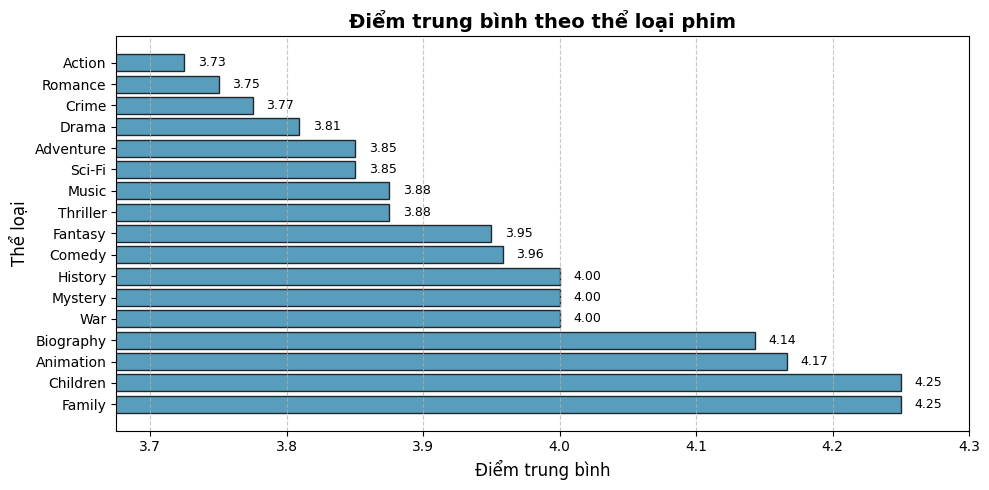

In [17]:
data = genre_avg.map(lambda x: (x[0], x[1][0])).collect()
genres = [item[0] for item in data]
ratings = [item[1] for item in data]

# === Sắp xếp theo rating giảm dần ===
sorted_idx = np.argsort(ratings)[::-1]
genres_sorted = [genres[i] for i in sorted_idx]
ratings_sorted = [ratings[i] for i in sorted_idx]

plt.figure(figsize=(10, 5))
bars = plt.barh(genres_sorted, ratings_sorted, color='#2E86AB', edgecolor='black', alpha=0.8)

# === Tinh chỉnh ===
x_min = min(ratings_sorted) - 0.05
x_max = max(ratings_sorted) + 0.05
plt.xlim(x_min, x_max)

for bar, rating in zip(bars, ratings_sorted):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{rating:.2f}', va='center', fontsize=9)

plt.xlabel('Điểm trung bình', fontsize=12)
plt.ylabel('Thể loại', fontsize=12)
plt.title('Điểm trung bình theo thể loại phim', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Part 03

In [2]:
import os
os.environ['PYTHONHASHSEED'] = '0'

from pyspark import SparkConf, SparkContext
conf = SparkConf().setMaster("local").setAppName("BigData")
sc = SparkContext.getOrCreate(conf=conf)

# Import các hàm cần thiết
import sys
sys.path.append('.')
from src.session_03 import (
    get_user_gender,
    load_ratings_with_user,
    join_ratings_gender,
    avg_rating_by_gender_per_movie
)

# Đường dẫn file
users_path = "data/users.txt"
ratings_paths = ["data/ratings_1.txt", "data/ratings_2.txt"]
movies_path = "data/movies.txt"   # dùng để lấy tên phim

# Đọc dữ liệu
user_gender = get_user_gender(sc, users_path)
ratings_full = load_ratings_with_user(sc, ratings_paths)

print("Số lượng ratings:", ratings_full.count())
print("Số lượng user-gender:", user_gender.count())

# Join để có (MovieID, (Rating, Gender))
joined = join_ratings_gender(ratings_full, user_gender)
print("Sau join:", joined.count())

# Tính trung bình theo (MovieID, Gender)
movie_gender_avg = avg_rating_by_gender_per_movie(joined)
print("Số phim có đánh giá:", movie_gender_avg.count())

# ===Lấy tên phim
def get_movie_titles(sc, movies_path):
    movies_rdd = sc.textFile(movies_path)
    return movies_rdd.map(lambda line: [x.strip() for x in line.split(',')]) \
                     .map(lambda x: (int(x[0]), x[1]))

titles = get_movie_titles(sc, movies_path)

# === Hiển thị kết quả ===
print("\n=== 5 phim có chênh lệch rating giữa nam và nữ lớn nhất ===")
for movie_id, avg_m, avg_f, diff in top_diff:
    name = titles.lookup(movie_id)[0]
    m_str = f"{avg_m:.2f}" if avg_m is not None else "N/A"
    f_str = f"{avg_f:.2f}" if avg_f is not None else "N/A"
    print(f"{name[:40]:<40} | M: {m_str} | F: {f_str} | diff: {diff:.2f}")

Số lượng ratings: 100
Số lượng user-gender: 50
Sau join: 100
Số phim có đánh giá: 50

=== 5 phim có chênh lệch rating giữa nam và nữ lớn nhất ===
The Departed (2006)                      | M: 4.50 | F: 2.00 | diff: 2.50
Forrest Gump (1994)                      | M: 2.50 | F: 5.00 | diff: 2.50
The Shawshank Redemption (1994)          | M: 3.00 | F: 5.00 | diff: 2.00
La La Land (2016)                        | M: 5.00 | F: 3.00 | diff: 2.00
The Godfather (1972)                     | M: 4.50 | F: 2.50 | diff: 2.00
